In [1]:
import pandas as pd

files = [
    "/content/03_aum_by_fund_house.csv",
    "/content/04_monthly_sip_inflows.csv",
    "/content/05_category_inflows.csv",
    "/content/06_industry_folio_count.csv",
    "/content/09_portfolio_holdings.csv"
]

for file in files:
    df = pd.read_csv(file)

    print("\n" + "="*50)
    print(file)
    print("="*50)

    print("Columns:")
    print(df.columns.tolist())

    print("\nFirst 3 rows:")
    print(df.head(3))


/content/03_aum_by_fund_house.csv
Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

First 3 rows:
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195

/content/04_monthly_sip_inflows.csv
Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

First 3 rows:
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                    9.1                4.80             NaN  
1                    8.2

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

In [3]:
nav = pd.read_csv("/content/02_nav_history_cleaned.csv")

perf = pd.read_csv("/content/07_scheme_performance_cleaned.csv")

txn = pd.read_csv("/content/08_investor_transactions_cleaned.csv")

aum = pd.read_csv("/content/03_aum_by_fund_house.csv")

sip = pd.read_csv("/content/04_monthly_sip_inflows.csv")

category = pd.read_csv("/content/05_category_inflows.csv")

folio = pd.read_csv("/content/06_industry_folio_count.csv")

holdings = pd.read_csv("/content/09_portfolio_holdings.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folio["month"] = pd.to_datetime(folio["month"])

txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

NAV Trend Analysis


In [5]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends (2022–2026)"
)

fig.show()

In [6]:
top10 = nav["amfi_code"].unique()[:10]

nav10 = nav[nav["amfi_code"].isin(top10)]

fig = px.line(
    nav10,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trends - Top 10 Schemes"
)

fig.show()

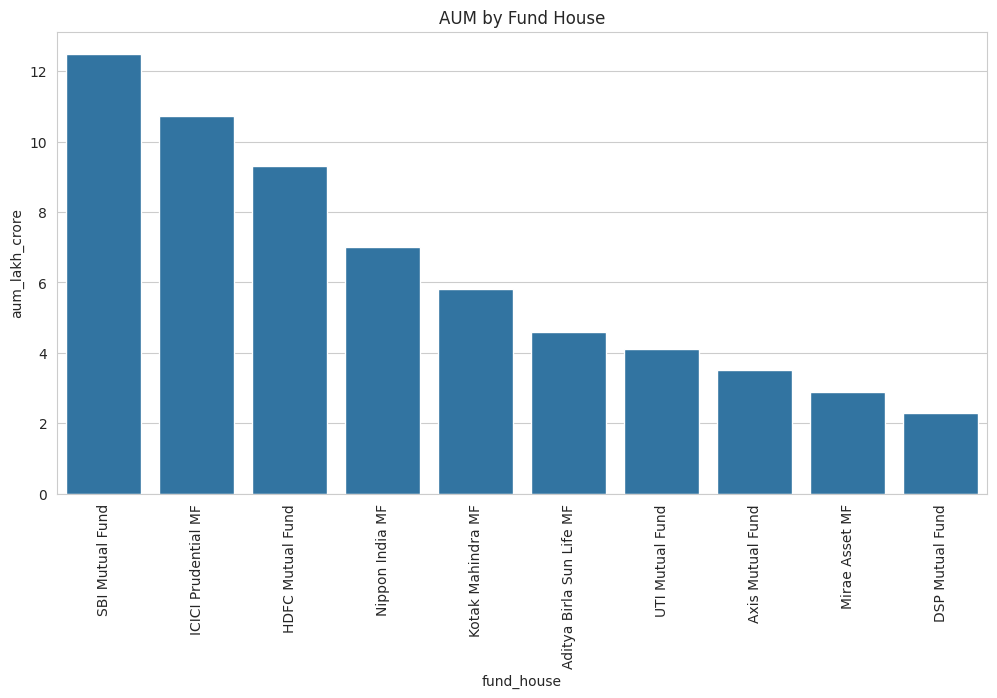

In [7]:
latest = aum.sort_values("date").groupby("fund_house").tail(1)

latest = latest.sort_values(
    "aum_lakh_crore",
    ascending=False
)

sns.barplot(
    data=latest,
    x="fund_house",
    y="aum_lakh_crore"
)

plt.xticks(rotation=90)
plt.title("AUM by Fund House")
plt.show()

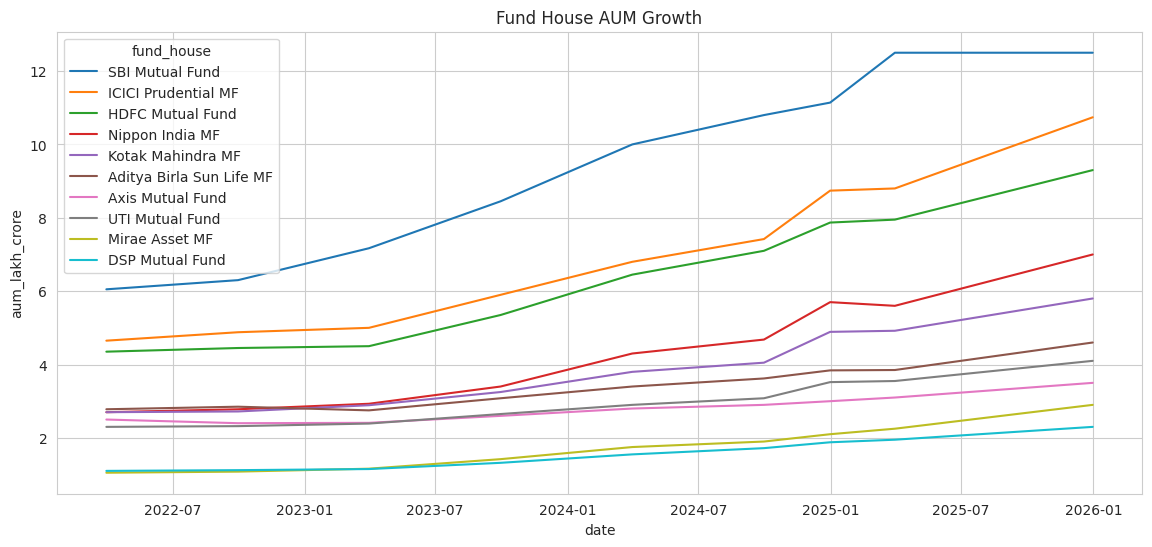

In [8]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Fund House AUM Growth")
plt.show()

In [9]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows"
)

fig.show()

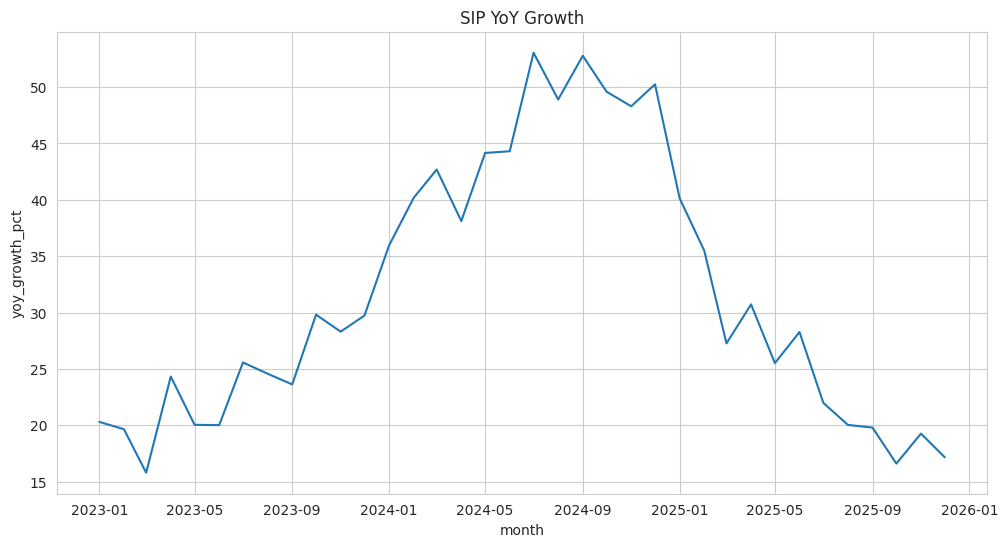

In [10]:
sns.lineplot(
    data=sip,
    x="month",
    y="yoy_growth_pct"
)

plt.title("SIP YoY Growth")
plt.show()

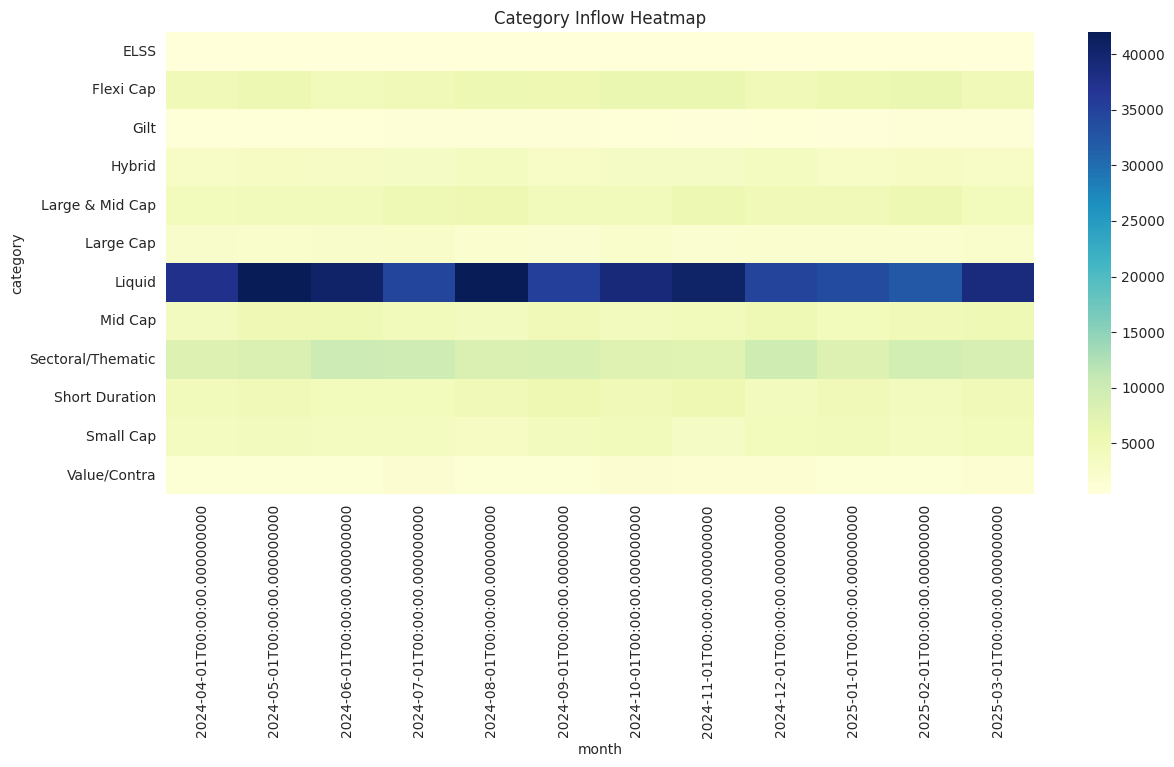

In [11]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.show()

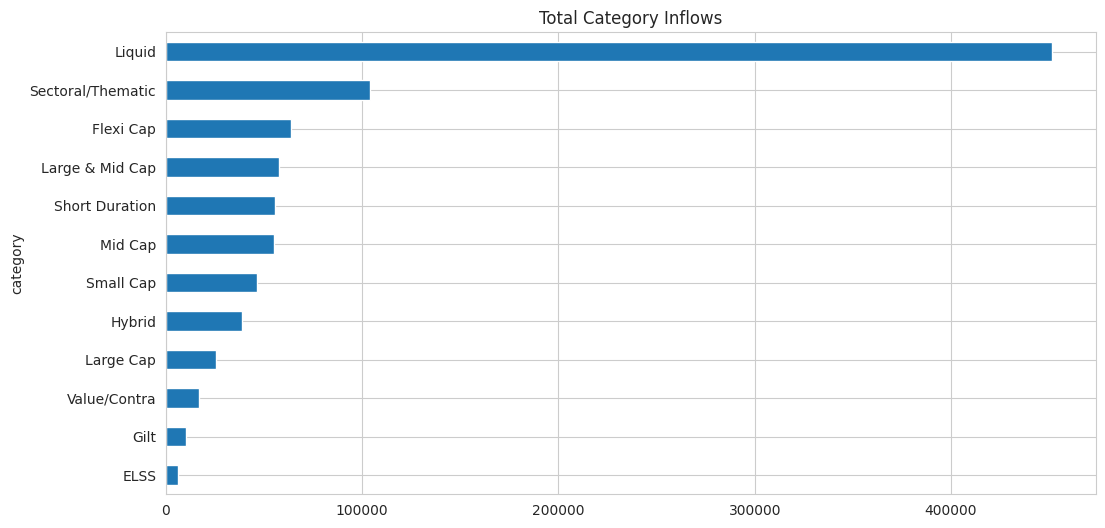

In [12]:
cat_sum = category.groupby(
    "category"
)["net_inflow_crore"].sum()

cat_sum.sort_values().plot.barh()

plt.title("Total Category Inflows")
plt.show()

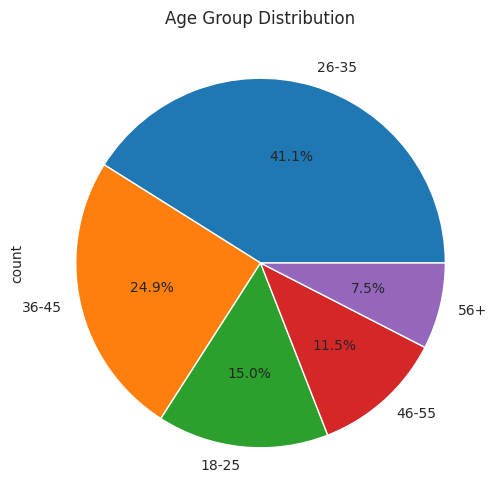

In [13]:
txn["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")
plt.show()

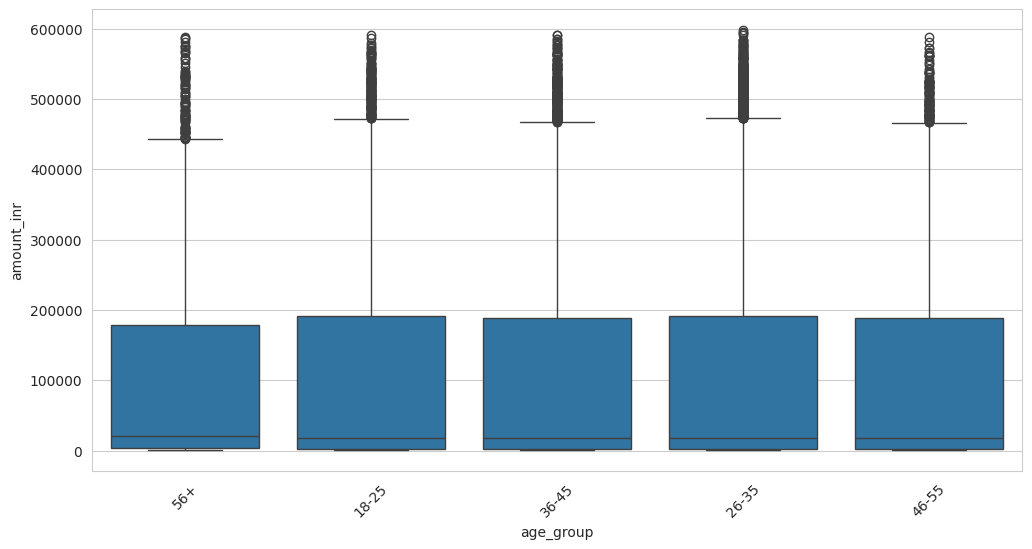

In [14]:
sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)
plt.show()

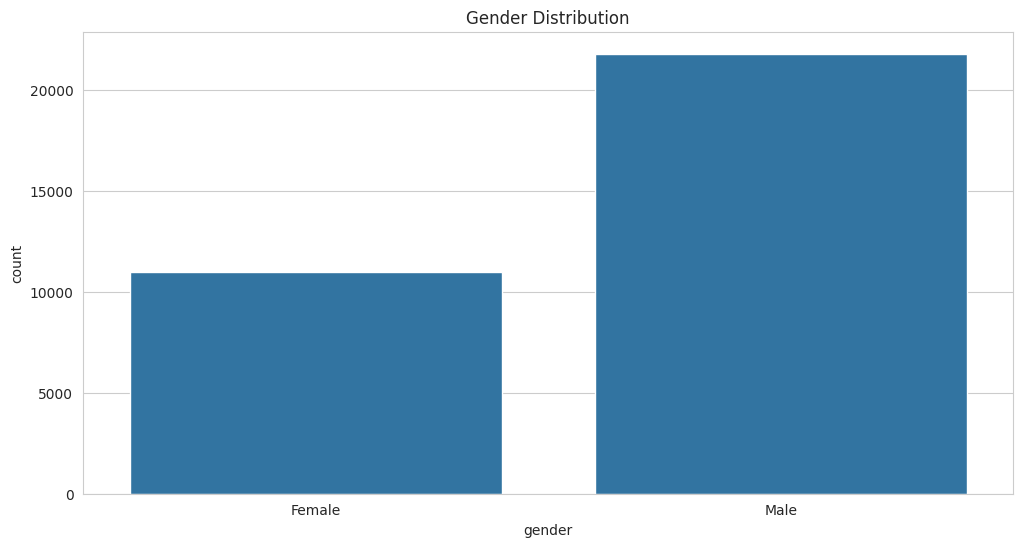

In [15]:
sns.countplot(
    data=txn,
    x="gender"
)

plt.title("Gender Distribution")
plt.show()

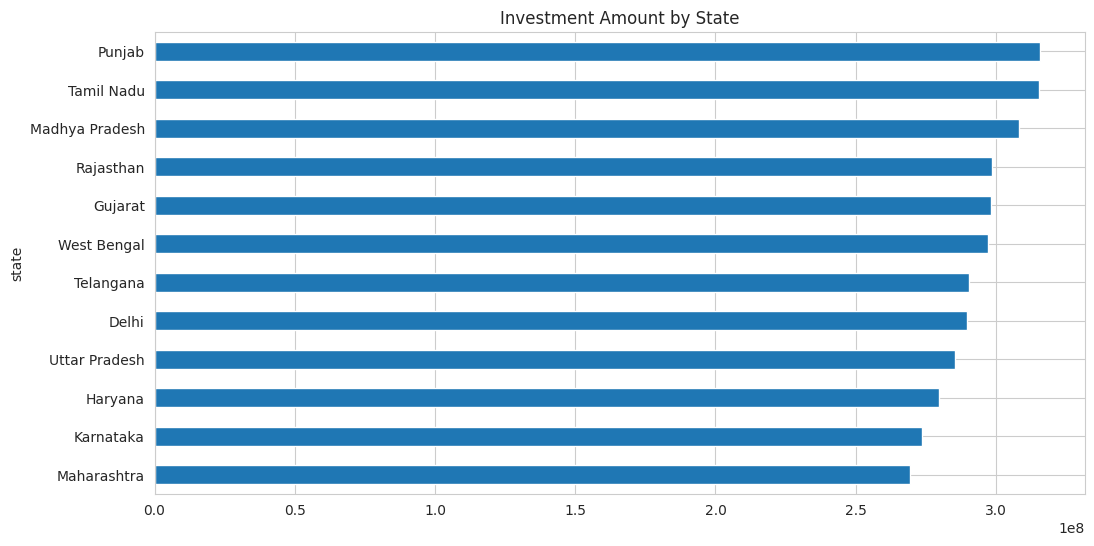

In [16]:
state_amt = (
    txn.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values()
)

state_amt.plot.barh()

plt.title("Investment Amount by State")
plt.show()

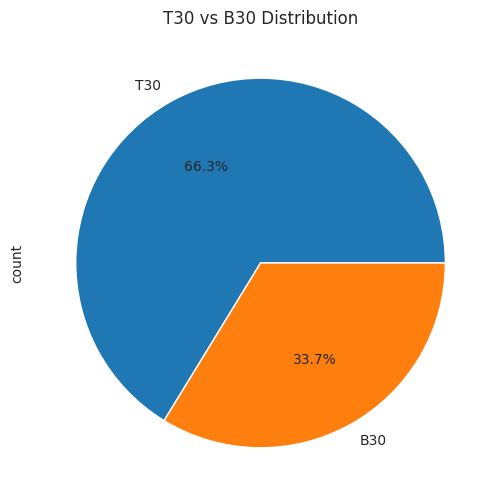

In [17]:
txn["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.show()

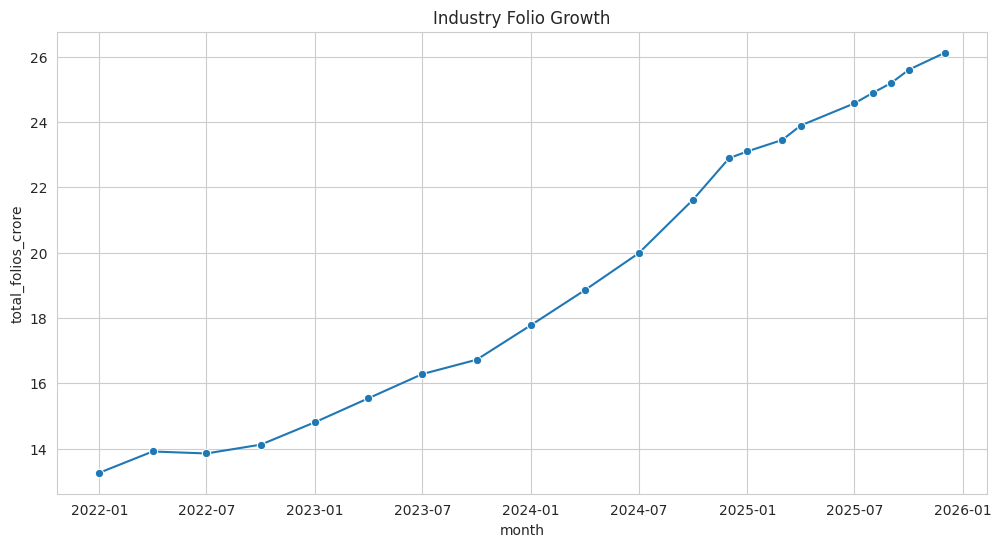

In [18]:
sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o"
)

plt.title("Industry Folio Growth")
plt.show()

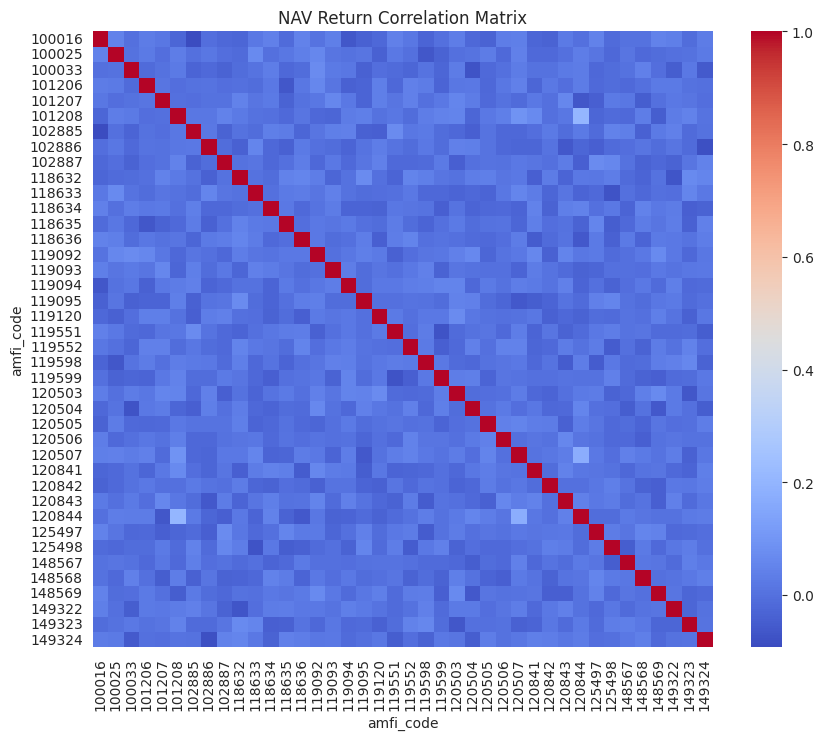

In [19]:
pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

In [20]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

fig = px.pie(
    values=sector.values,
    names=sector.index,
    hole=0.5,
    title="Sector Allocation"
)

fig.show()

### Insight 1
NAV values showed a generally upward trend between 2022 and 2026.

### Insight 2
SBI Mutual Fund maintained one of the highest AUM values among all fund houses.

### Insight 3
Monthly SIP inflows increased steadily and reached record highs by late 2025.

### Insight 4
Large Cap and Mid Cap categories attracted substantial net inflows.

### Insight 5
Retail participation increased significantly as reflected in folio growth.

### Insight 6
Most investor transactions originated from T30 cities.

### Insight 7
The 26–35 age group contributed a significant share of investments.

### Insight 8
Banking and Financial sectors occupied a large share of portfolio allocations.

### Insight 9
Fund returns displayed positive correlations during market uptrends.

### Insight 10
Expense ratios remained within expected industry ranges for most schemes.

In [21]:
plt.savefig(
    "chart_name.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 1200x600 with 0 Axes>

In [22]:
import os

print(os.listdir())

['.config', '02_nav_history_cleaned.csv', '08_investor_transactions_cleaned.csv', '03_aum_by_fund_house.csv', 'chart_name.png', '07_scheme_performance_cleaned.csv', '07_scheme_performance.csv', '01_fund_master.csv', '06_industry_folio_count.csv', '08_investor_transactions.csv', '05_category_inflows.csv', '04_monthly_sip_inflows.csv', '10_benchmark_indices.csv', '02_nav_history.csv', '09_portfolio_holdings.csv', 'sample_data']
